In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

asset_dir = '../Assets/'

# Gaussian Smoothing Kernel

In [14]:
def gaussian_function(u, v, sigma):
    return (1 / (2 * np.pi * (sigma**2))) * np.exp(-((u**2 + v**2) / (2*sigma**2))) 

In [15]:
def create_gaussian_kernel(size, sigma):
    """Create a Gaussian smoothing kernel"""
    kernel = np.zeros((size, size))
    center = size // 2
    
    for i in range(size):
        for j in range(size):
            x, y = i - center, j - center
            kernel[i, j] = gaussian_function(x, y, sigma)
    
    kernel = kernel / np.sum(kernel)
    return kernel

# LoG Kernel

In [16]:
def log_function(x,y,sigma):
    r_squared = x**2 + y**2
    return -(1 / (np.pi * sigma**4)) * (1 - r_squared / (2 * sigma**2)) * np.exp(-r_squared / (2 * sigma**2))

In [17]:
def create_sharpening_kernel(size, sigma):
    kernel = np.zeros((size, size))
    center = size // 2
    
    for i in range(size):
        for j in range(size):
            x, y = i - center, j - center
            kernel[i, j] = log_function(x,y,sigma)

    return kernel

# Image

In [90]:
img_rgb = cv2.imread(asset_dir + '/generic/Lena.jpg')

sigma_smooth = 1
sigma_sharp = 1.2

smoothing_kernel = create_gaussian_kernel(5, sigma_smooth)
sharpening_kernel = create_sharpening_kernel(7, sigma_sharp)

print("Smoothing kernel (5x5):")
print(smoothing_kernel)

print("\nSharpening kernel (7x7):")
print(sharpening_kernel)

Smoothing kernel (5x5):
[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]

Sharpening kernel (7x7):
[[ 0.00155576  0.00590957  0.01178272  0.01433223  0.01178272  0.00590957
   0.00155576]
 [ 0.00590957  0.01696794  0.01991063  0.01488552  0.01991063  0.01696794
   0.00590957]
 [ 0.01178272  0.01991063 -0.02342189 -0.07080987 -0.02342189  0.01991063
   0.01178272]
 [ 0.01433223  0.01488552 -0.07080987 -0.15350593 -0.07080987  0.01488552
   0.01433223]
 [ 0.01178272  0.01991063 -0.02342189 -0.07080987 -0.02342189  0.01991063
   0.01178272]
 [ 0.00590957  0.01696794  0.01991063  0.01488552  0.01991063  0.01696794
   0.00590957]
 [ 0.00155576  0.00590957  0.01178272  0.01433223  0.01178272  0.00590957
   0.00155576]]


In [91]:
img_rgb = cv2.imread(asset_dir + '/generic/Lena.jpg')
bc, gc, rc = cv2.split(img_rgb)

zeros = np.zeros_like(bc)

bc_smooth = cv2.filter2D(bc, -1, smoothing_kernel)
gc_smooth = cv2.filter2D(gc, -1, smoothing_kernel)
rc_smooth = cv2.filter2D(rc, -1, smoothing_kernel)

bc_sharp = cv2.filter2D(bc.astype(np.float32), -1, sharpening_kernel)
gc_sharp = cv2.filter2D(gc.astype(np.float32), -1, sharpening_kernel)
rc_sharp = cv2.filter2D(rc.astype(np.float32), -1, sharpening_kernel)

zeros_sharp = np.zeros_like(bc_sharp)

img_gauss = cv2.merge([bc_smooth, gc_smooth, rc_smooth])
img_laplace = cv2.merge([bc_sharp, gc_sharp, rc_sharp])

bc = cv2.merge([bc, zeros, zeros])
gc = cv2.merge([zeros, gc, zeros])
rc = cv2.merge([zeros, zeros, rc])

bc_smooth_inv = cv2.merge([zeros+255, 255-bc_smooth, 255-bc_smooth])
gc_smooth_inv = cv2.merge([255-gc_smooth, zeros+255, 255-gc_smooth])
rc_smooth_inv = cv2.merge([255-rc_smooth, 255-rc_smooth, zeros+255])

bc_smooth = cv2.merge([bc_smooth, zeros, zeros])
gc_smooth = cv2.merge([zeros, gc_smooth, zeros])
rc_smooth = cv2.merge([zeros, zeros, rc_smooth])

bc_sharp_uint8 = bc_sharp.astype(np.uint8)
gc_sharp_uint8 = gc_sharp.astype(np.uint8)
rc_sharp_uint8 = rc_sharp.astype(np.uint8)

ones = np.ones_like(bc_sharp_uint8) * 255

bc_sharp_inv = cv2.merge([ones, bc_sharp_uint8, bc_sharp_uint8]) 
gc_sharp_inv = cv2.merge([gc_sharp_uint8, ones, gc_sharp_uint8])
rc_sharp_inv = cv2.merge([rc_sharp_uint8, rc_sharp_uint8, ones])

bc_sharp = cv2.merge([bc_sharp, zeros_sharp , zeros_sharp])
gc_sharp = cv2.merge([zeros_sharp , gc_sharp, zeros_sharp])
rc_sharp = cv2.merge([zeros_sharp , zeros_sharp , rc_sharp])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.438114..40.85708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-50.443317..31.778687].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.438114..40.85708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-49.53476..31.173317].


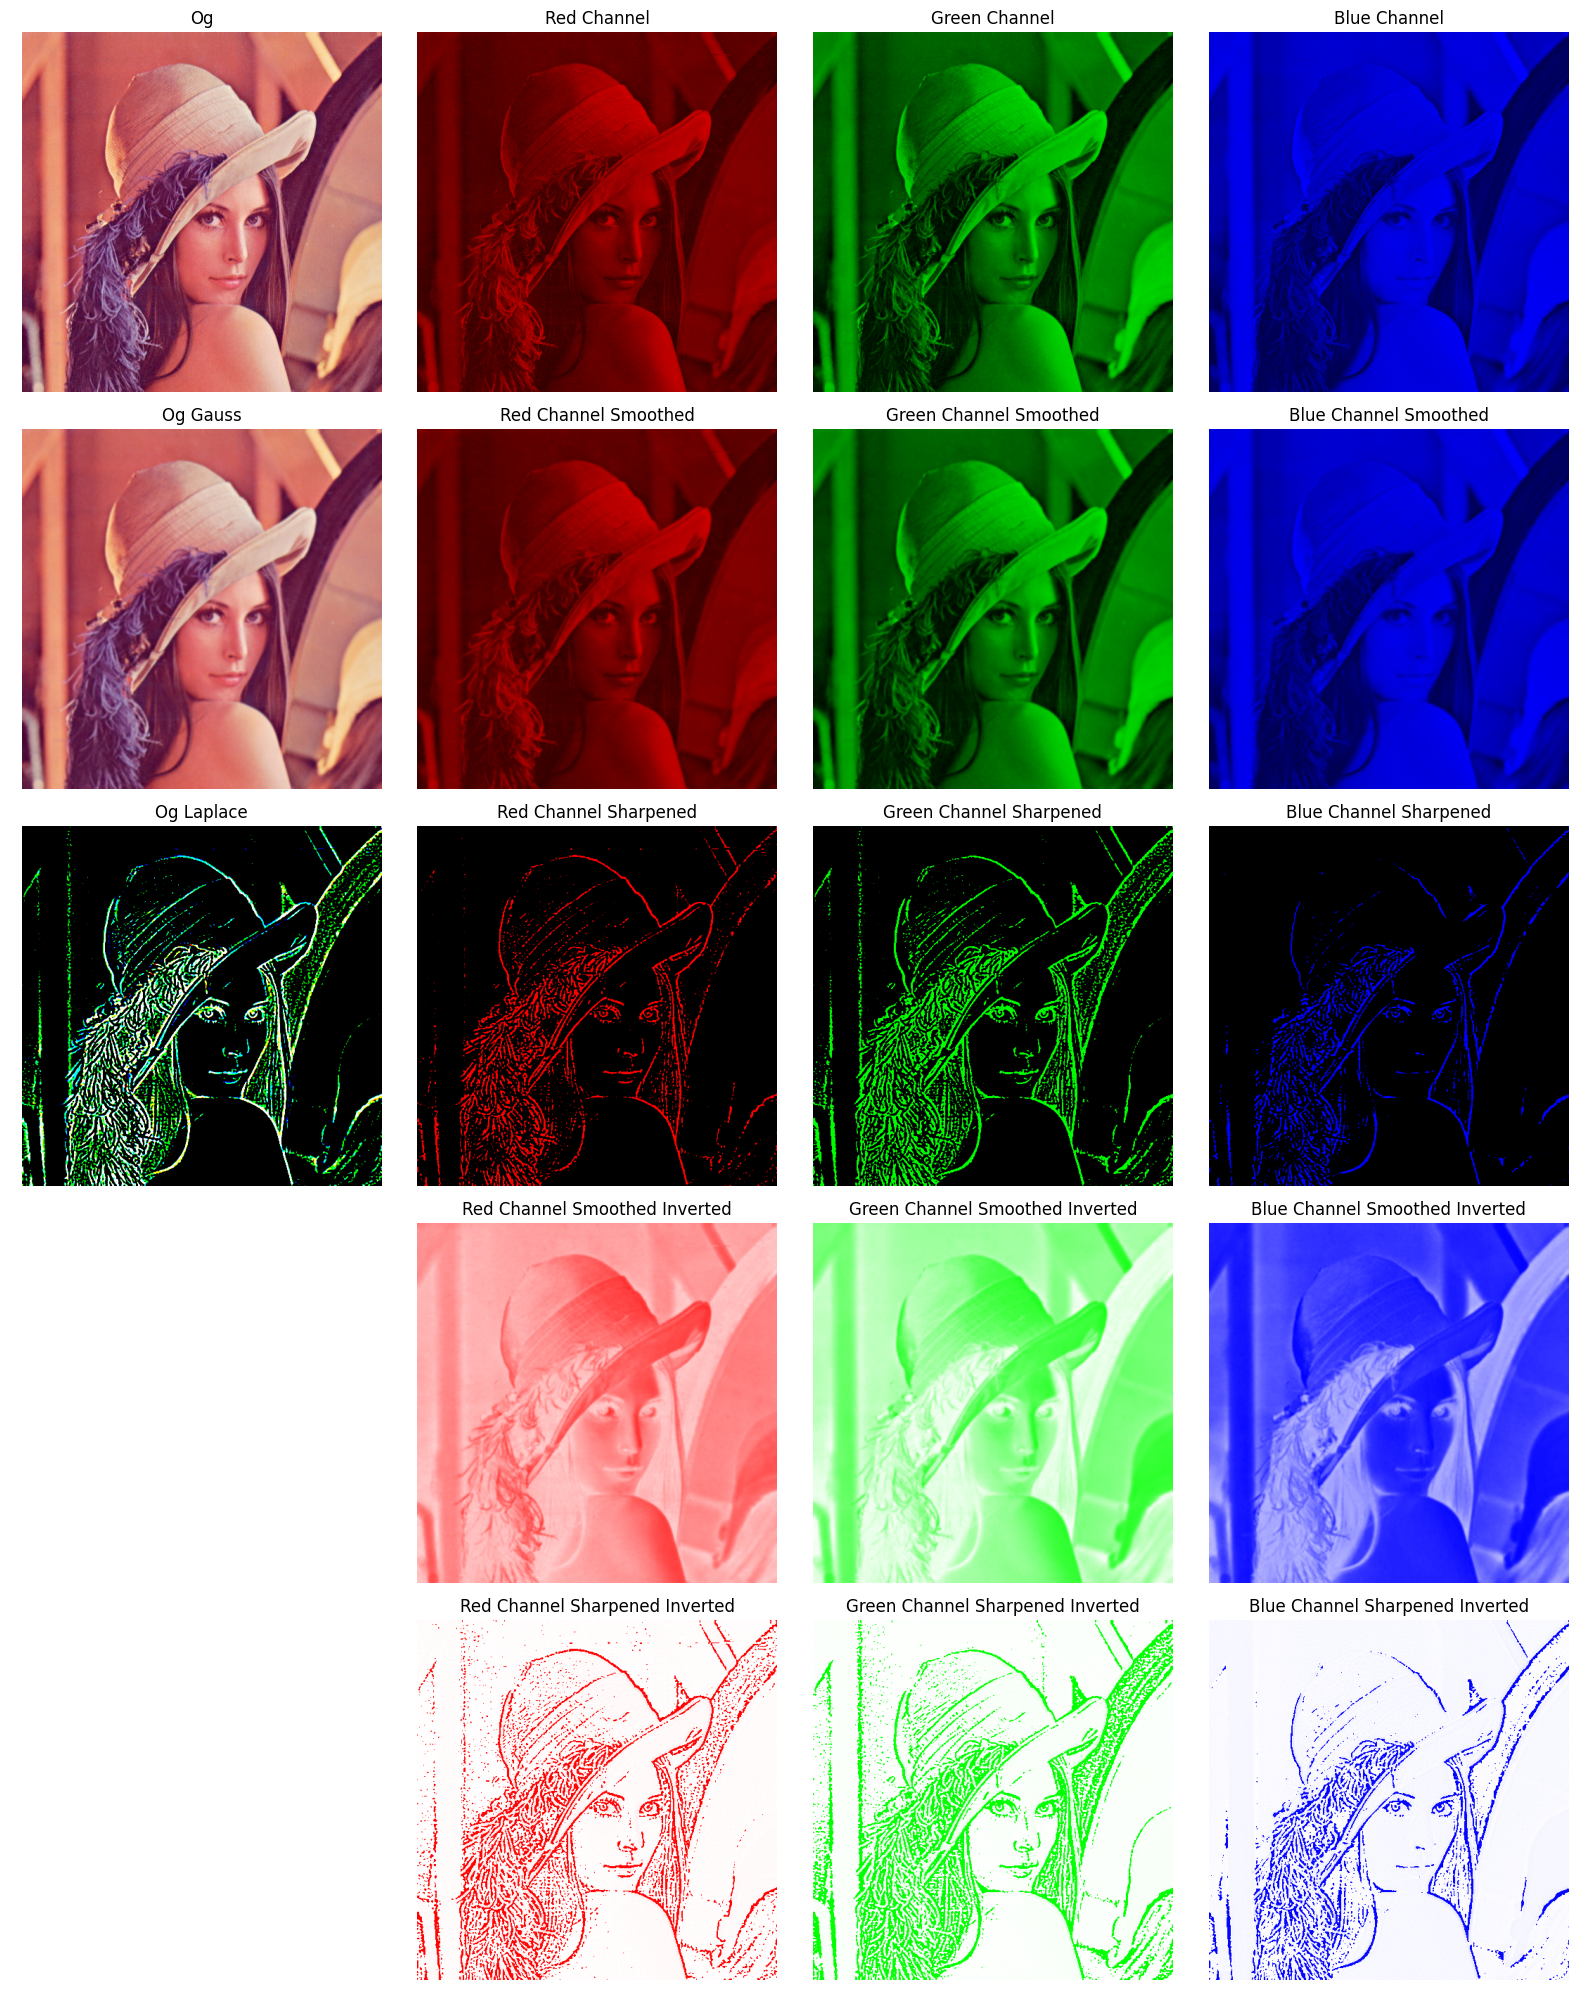

In [92]:
fig, axs = plt.subplots(5, 4, figsize=(16, 20))

for ax in axs.flat:
    ax.axis("off")

axs[0, 0].imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title("Og")
axs[0, 1].imshow(bc)
axs[0, 1].set_title("Red Channel")
axs[0, 2].imshow(gc)
axs[0, 2].set_title("Green Channel")
axs[0, 3].imshow(rc)
axs[0, 3].set_title("Blue Channel")

axs[1, 0].imshow(cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB))
axs[1, 0].set_title("Og Gauss")
axs[1, 1].imshow(bc_smooth)
axs[1, 1].set_title("Red Channel Smoothed")
axs[1, 2].imshow(gc_smooth)
axs[1, 2].set_title("Green Channel Smoothed")
axs[1, 3].imshow(rc_smooth)
axs[1, 3].set_title("Blue Channel Smoothed")

axs[2, 0].imshow(cv2.cvtColor(img_laplace, cv2.COLOR_BGR2RGB))
axs[2, 0].set_title("Og Laplace")
axs[2, 1].imshow(bc_sharp)
axs[2, 1].set_title("Red Channel Sharpened")
axs[2, 2].imshow(gc_sharp)
axs[2, 2].set_title("Green Channel Sharpened")
axs[2, 3].imshow(rc_sharp)
axs[2, 3].set_title("Blue Channel Sharpened")

# inverted smoothed channels
axs[3, 0].axis("off")
axs[3, 1].imshow(bc_smooth_inv)
axs[3, 1].set_title("Red Channel Smoothed Inverted")
axs[3, 2].imshow(gc_smooth_inv)
axs[3, 2].set_title("Green Channel Smoothed Inverted")
axs[3, 3].imshow(rc_smooth_inv)
axs[3, 3].set_title("Blue Channel Smoothed Inverted")

# inverted sharpened channels
axs[4, 0].axis("off")
axs[4, 1].imshow(bc_sharp_inv)
axs[4, 1].set_title("Red Channel Sharpened Inverted")
axs[4, 2].imshow(gc_sharp_inv)
axs[4, 2].set_title("Green Channel Sharpened Inverted")
axs[4, 3].imshow(rc_sharp_inv)
axs[4, 3].set_title("Blue Channel Sharpened Inverted")


plt.tight_layout()
plt.show()